In [1]:
import h5py
import numpy as np

h5path = "/home/albert/Baikal2025/data_manager/h5datasets/exp.h5"

In [2]:
with h5py.File(h5path, 'r') as hf:
    magic_group = hf['exp/raw/labels']
    channels_group = hf['exp/raw/channels']
    unique_strings_group = hf['exp/raw/num_un_strings']
    for part in magic_group:
        magic_numbers = magic_group[part]['data'][:]
        channels = channels_group[part]['data'][:]
        unique_strings = unique_strings_group[part]['data'][:]
        print(f"Part: {part}, Magic Numbers: {magic_numbers}, Channels shape: {channels.shape}, Unique Strings: {unique_strings}")

Part: part_s2020_c01_r0027, Magic Numbers: [0 0 0 ... 0 0 0], Channels shape: (1372329,), Unique Strings: [7 7 7 ... 7 7 7]
Part: part_s2020_c01_r0116, Magic Numbers: [0 0 0 ... 0 0 0], Channels shape: (1313631,), Unique Strings: [7 7 7 ... 7 7 7]
Part: part_s2020_c01_r0188, Magic Numbers: [0 0 0 ... 0 0 0], Channels shape: (1741114,), Unique Strings: [7 7 7 ... 7 7 7]
Part: part_s2020_c02_r0015, Magic Numbers: [0 0 0 ... 0 0 0], Channels shape: (1359146,), Unique Strings: [8 8 8 ... 8 8 8]
Part: part_s2020_c02_r0149, Magic Numbers: [0 0 0 ... 0 0 0], Channels shape: (1656530,), Unique Strings: [7 7 7 ... 6 7 7]
Part: part_s2020_c02_r0206, Magic Numbers: [0 0 0 ... 0 0 0], Channels shape: (1803293,), Unique Strings: [8 8 8 ... 8 8 8]
Part: part_s2020_c02_r0357, Magic Numbers: [0 0 0 ... 0 0 0], Channels shape: (1971454,), Unique Strings: [7 7 7 ... 7 7 7]
Part: part_s2020_c03_r0012, Magic Numbers: [0 0 0 ... 0 0 0], Channels shape: (1437882,), Unique Strings: [8 8 8 ... 8 8 8]
Part: pa

In [39]:
h5path = "/net/62/home3/ivkhar/Baikal/data/h5s/baikal_mc_merged.h5"
with h5py.File(h5path, 'r') as hf:
    print(hf['muatm_2020/clusters_centers/data'][:])
    print(hf['muatm_2020/coords_are_cluster_centered/data'][()])
    mu_data = hf['muatm_2020/raw/data']
    zs = []
    for p in list(mu_data.keys())[0:100:10]:
        zs.append(mu_data[p+'/data'][:,4])
zs = np.concat(zs)

[[ 2.15385616e+02  1.16251927e+02  4.45793382e-01]
 [ 8.50812536e+00 -5.58244649e+00 -5.40172060e-04]
 [-4.56787589e+01  2.89528296e+02  1.11286316e+00]
 [ 2.90178993e+02 -1.07529820e+02 -1.47777268e+00]
 [ 6.12084984e+01 -3.01591814e+02 -1.25065785e+00]
 [-2.57740120e+02 -1.38016697e+02 -2.06323713e-02]
 [-2.71862360e+02  1.46940425e+02  1.18843507e+00]]
True


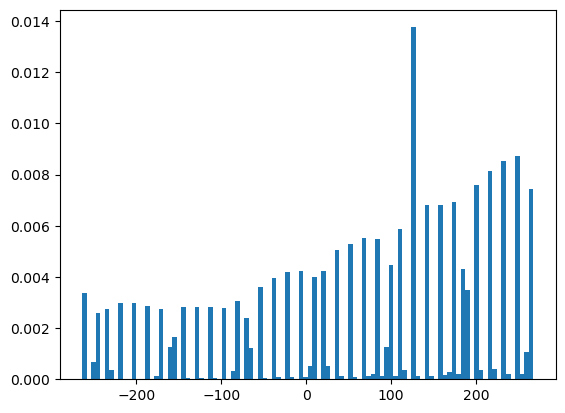

In [41]:
import matplotlib.pyplot as plt

plt.hist(zs, 100, density=True)
plt.show()

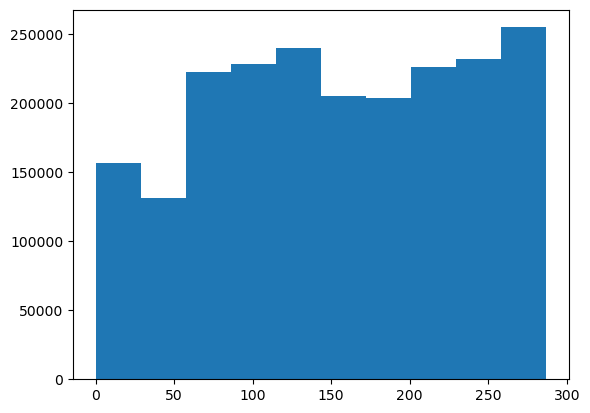

In [3]:
import matplotlib.pyplot as plt

plt.hist(channels)
plt.show()

In [1]:
import uproot as ur
import numpy as np
import awkward as ak
from pprint import pprint

In [9]:
with ur.open("/net/62/home/albert/Baikal/Data/reco_exp_root_files/2020_cl6_run325_scl_nu_DATA2020.root") as file:
    print(file.keys())
    keys = file['Events'].keys()
    q = file['Events/BEvent./BEvent.fPulses/BEvent.fPulses.fAmplitude'].array(library='np')
    x = file['Events/BRecoMuon./BRecoMuon.fTRes'].array(library='np')
    #pprint([k for k in file['Events'].keys()][30:], compact=True)#/BGeomTel.BGeomTel.fOMs/BGeomTel.BGeomTel.fOMs.fPosition"])
    # pprint(file['Events/BEvent./BEvent.fPulseN'].array(library="np"))
    # channels = file['Events/BEvent./BEvent.fPulses/BEvent.fPulses.fChannelID'].array(library='np')
    # active_clusters = [np.unique(ch // 288) for ch in channels]
    # ampls = file['Events/BEvent./BEvent.fPulses/BEvent.fPulses.fAmplitude'].array(library='np')
    # coords = np.array(ak.unzip(file["Events/BGeomTel./BGeomTel.BGeomTel/BGeomTel.BGeomTel.fOMs/BGeomTel.BGeomTel.fOMs.fPosition"].array()))
    # print(file['Events/BEvent./BEvent.fPulseN'].array(library="np", entry_start=0, entry_stop=1))
    
    # pulses_nums = file['Events/BEvent./BEvent.fPulseN'].array(library="np")[:23]
    # print(np.argwhere(pulses_nums > 0))
    #print(np.argwhere(pulses_nums > 0)[0][0])

['Events;1']


In [14]:
(q[1]>3.)

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
        True, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False])

In [8]:
x[1]

array([-4.9609375 ,  4.58789062, -1.625     ,  0.24609375,  5.44140625,
       -6.19921875,  2.46289062])

In [55]:
[k for k in keys if 'hit' in k.lower()]

['BEvent./BEvent.fPulses/BEvent.fPulses.fHitNum',
 'BRecoMuon./BRecoMuon.fNHitsInit',
 'BRecoMuon./BRecoMuon.fNHits',
 'BRecoMuon./BRecoMuon.fNHitsRecoll',
 'BRecoMuon./BRecoMuon.fNHits_clHM',
 'BRecoMuon./BRecoMuon.fNHits_clLM',
 'BRecoMuon./BRecoMuon.fHitLLTime',
 'BRecoMuon./BRecoMuon.fHitLLCharge',
 'BRecoMuon./BRecoMuon.fMinPnonHit',
 'BRecoMuon./BRecoMuon.fMaxPhit',
 'BRecoMuon./BRecoMuon.fPHit',
 'BRecoMuon./BRecoMuon.fPHit_spe',
 'BRecoMuon./BRecoMuon.fPnonHit',
 'BRecoMuon./BRecoMuon.fPHitSum',
 'BRecoMuon./BRecoMuon.fPHitSum_spe',
 'BRecoMuon./BRecoMuon.fNnonHit_22m',
 'BRecoMuon./BRecoMuon.fNnonHit_30m',
 'BRecoMuon./BRecoMuon.fNHits_22m',
 'BRecoMuon./BRecoMuon.fNHits_30m']

In [30]:
ampls[24:]

array([array([ 0.5495728 ,  1.6822332 ,  0.9917324 , 23.622414  ,  0.2193911 ,
               1.3972896 ,  0.84952706,  0.6075795 ,  1.3685665 ,  0.40447277,
               2.1363583 ,  1.3333035 ,  0.56192034,  1.1025666 ,  0.7974092 ,
               0.90253806,  1.5873362 ,  0.81924385,  0.79153746,  1.2836637 ,
               0.6345931 ,  1.0746716 ,  0.25819907,  1.086014  ,  1.2268723 ,
               0.9572732 ,  0.94391423,  1.7081739 ,  0.43678376,  1.4446819 ,
               1.0385987 ,  0.20316859,  0.5350518 ,  1.4918292 ,  1.2462729 ],
             dtype=float32)                                                    ,
       array([4.3728967 , 1.453564  , 0.6754995 , 0.47828695, 0.57975626,
              1.4080708 , 1.4260242 , 0.7836257 , 1.4371263 , 0.677169  ,
              0.83275473, 0.8181878 , 1.1519555 , 0.5466279 , 0.38770768,
              1.5483447 , 0.27853745, 1.3071766 , 0.30095896, 1.0794909 ,
              0.98578954, 1.2261024 , 1.1874397 , 1.1418703 , 2.03754

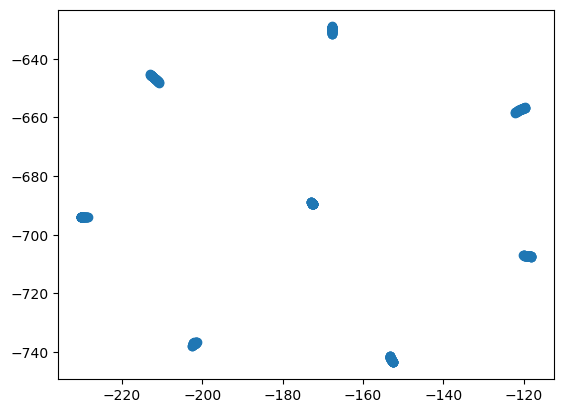

In [6]:
# Reshape to group OMs into clusters
num_clusters = coords.shape[-1] // 288
coordinates = coords.reshape(*coords.shape[:-1], num_clusters, 288)

# Calculate mean for each cluster
cl_centers = np.mean(coordinates, axis=(1, -1))
cl_centers

import matplotlib.pyplot as plt

plt.plot(coordinates[0, 0, 0, :], coordinates[1, 0, 0, :], 'o')

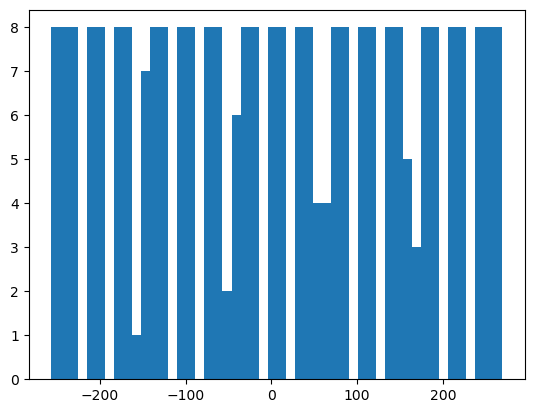

In [42]:
plt.hist(coordinates[2,4].flatten()-354, bins=50)
plt.show()

In [13]:
coordinates.shape

(3, 25000, 1, 288)

In [37]:
cl_centers.shape
#np.repeat( np.transpose(cl_centers, axes=(1,0)), 288, axis=1).shape

(3, 1)

(3, 25000, 1, 288)


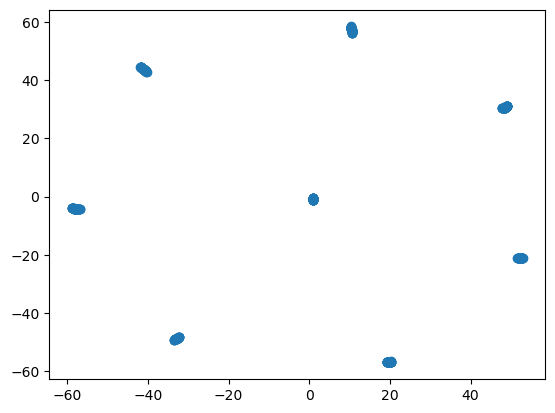

In [50]:
#cl_centers_broad = np.expand_dims( np.repeat(cl_centers.T, 288, axis=2), axis=1 )
coordinates += -cl_centers[:,:,None,None]
print(coordinates.shape)
plt.plot(coordinates[0, 0, 0, :], coordinates[1, 0, 0, :], 'o')

In [51]:
coordinates.mean(axis=(1,2,3))

array([-4.89106040e-15, -5.60652956e-15, -1.11402995e-14])

In [28]:
cl_centers_broad.shape

(1, 1, 864)

In [ ]:
def get_start_index(rf):
    test = rf['Events/BEvent./BEvent.fPulseN'].array(library="np", entry_start=0, entry_stop=1)[0]
    return 1 if test == 0 else 0

def process_file(rf_path, id_prefix, cl_centers):
    take_single_cluster = True
    try:
        with ur.open(rf_path) as rf:
            # init dict for out data
            res_dict = {}
            # get first index
            st = get_start_index(rf)
            # Read channels and identify clusters
            num_channels = rf['Events/BEvent./BEvent.fPulseN'].array(library="np")[st:]
            channels = rf['Events/BEvent./BEvent.fPulses/BEvent.fPulses.fChannelID'].array(library='np')[st:]
            active_clusters = [np.unique(ch // 288) for ch in channels]
            num_un_clusters = np.array([len(cl) for cl in active_clusters])
                            
            # First, get masks and identify clusters
            if take_single_cluster:
                mask_single, cluster_ids = get_single_mask(active_clusters, num_un_clusters, take_clust_num)
                mask_multi, cluster_ids_multi = get_multi_mask(active_clusters, num_un_clusters)
                nums_multi = num_un_clusters[mask_multi]
                if split_multi:
                    cluster_ids_multi_flat = np.array([ cl for clss in cluster_ids_multi for cl in clss  ])
                    cluster_ids = np.concatenate( (cluster_ids,cluster_ids_multi_flat), axis=0 )
            # Read data
            data = [rf[p].array(library="np")[st:] for p in pathes_data]
            
            # Get data for multicluster events before modifying variables
            if split_multi:    
                data_multi = [d[mask_multi] for d in data]
                data_multi = flatten_multi(data_multi, channels[mask_multi], cluster_ids_multi)
                data_multi = [np.array(d, dtype=object) for d in data_multi]
                num_channels_multi = np.array([ len(chs) for chs in data_multi[-1] ])
            # Now extract data for single events
            if take_single_cluster:
                data = [ d[mask_single] for d in data ]
                num_channels = num_channels[mask_single]
                # And extend it for multi-cluster events
                if split_multi:
                    data = [ np.concatenate( (ds,dm), axis=0 ) for ds,dm in zip(data,data_multi) ]
                    num_channels = np.concatenate( (num_channels,num_channels_multi), axis=0 )

            # Processing data
            ev_starts = np.concatenate(([0], np.cumsum(num_channels))).astype(np.int64)
            
            # Falttern and sort
            r_data = np.array([np.concatenate(d) for d in data])
            sort_idxs = np.concatenate([np.argsort(r_data[1, ev_starts[i]:ev_starts[i+1]]) + ev_starts[i] for i in range(len(ev_starts)-1)])
            r_data = r_data[:, sort_idxs]
            
            # Read coordinates; broadcast, if needed, for unniform processing
            coordinates = np.array(ak.unzip(rf[path_geometry].array()))[:,st:]
            if coords_are_same:
                coordinates = np.repeat( coordinates, channels.shape[0], axis=1 )
            coordinates = np.transpose( cast_to_single( np.transpose(coordinates, (1,0,2)), mask_single, mask_multi, nums_multi, take_single_cluster, split_multi),
                                    (1,0,2) )

            # Read out coordinates of trigered detectors
            channels = r_data[-1].astype(np.int32)
            tr_coord = [ [coordinates[j,i,channels[ev_starts[i]:ev_starts[i+1]]] for i in range(len(ev_starts)-1)] for j in range(3) ]
            tr_coord = np.array( [ np.concatenate( tr_coord[i], axis=0 ) for i in range(len(tr_coord)) ]  )
            r_data = np.concatenate( (r_data,tr_coord), axis=0 )

            # Exclude hits with big time residuals - known bug
            if exclude_big_ts:
                mask = np.logical_and(np.abs(r_data[1]) <= t_threshold, ~np.isnan(r_data[1,:]))
                r_data = r_data[:, mask]
                shifts = np.array([ np.sum( ~mask[ev_starts[i]:ev_starts[i+1]] ) for i in range(len(ev_starts)-1) ])
                shifts = np.cumsum(shifts)
                ev_starts[1:] = ev_starts[1:]-shifts
            
            # Make so that avg time is zero
            if center_times:
                ts_sum = np.array([ np.sum( r_data[1,ev_starts[i]:ev_starts[i+1]] ) for i in range(len(ev_starts)-1) ])
                ts_avg = ts_sum/(ev_starts[1:]-ev_starts[:-1])
                r_data[1] = np.concatenate([r_data[1, ev_starts[i]:ev_starts[i+1]] - ts_avg[i] for i in range(len(ev_starts)-1)])
            
            # Now shift coordinates to center. Not earlier - important for tres cal
            if shift_coords_to_cl_center:
                cl_centers_broad = np.expand_dims( np.repeat( np.transpose(cl_centers, axes=(1,0)), 288, axis=1), axis=1 )
                coordinates += -cl_centers_broad
                # recalculate coordinates
                channels = r_data[3].astype('int')
                tr_coord = [ [coordinates[j,i,channels[ev_starts[i]:ev_starts[i+1]]] for i in range(len(ev_starts)-1)] for j in range(3) ]
                tr_coord = np.array( [ np.concatenate( tr_coord[i], axis=0 ) for i in range(len(tr_coord)) ]  )
                r_data[-3:] = tr_coord

            # Define results
            # Get number of unique string
            sig_strings = r_data[3] // 36
            un_strings = [ set(sig_strings[ev_starts[i]:ev_starts[i+1]]) for i in range(len(ev_starts)-1)  ]
            res_dict['raw/num_un_strings'] = np.array([ len(s) for s in un_strings ]).astype('int')
            # Make event ids
            ev_ids = np.arange(rf['Events/BEvent./BEvent.fPulseN'].num_entries-st)
            if split_multi:
                ids_multi = ev_ids[mask_multi]
                ids_multi = np.repeat( ids_multi, nums_multi )
            if take_single_cluster:
                ev_ids = ev_ids[mask_single]
                if split_multi:
                    ev_ids = np.concatenate( (ev_ids,ids_multi) )
            ev_ids = np.array([ f"{particle}_{id_prefix}_{str(int(ev_id))}" for ev_id in ev_ids ]).astype('bytes')
            res_dict['ev_ids'] = ev_ids
            # Data
            res_dict['raw/cluster_ids'] = cluster_ids
            res_dict['raw/data'] = np.transpose( r_data[[0,1,4,5,6]], (1,0) )
            res_dict['raw/labels'] = r_data[2]
            res_dict['raw/channels'] = r_data[3]
            res_dict['raw/ev_starts'] = ev_starts
            logging.info(f"Successfully processed file: {os.path.basename(rf_path)}, ({len(ev_ids)} events)")
            result_q.put((True, res_dict, id_prefix))
    
    except Exception as e:
        print(traceback.format_exc())
        print(f"Error processing file {rf_path}: {str(e)}")
        result_q.put((False, None, id_prefix))


83.35

: 